In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/application_train.csv')
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['TARGET'].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean()*100:.1f}%")

Shape: (307511, 122)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.1%


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/application_train.csv')

#EDA

In [ ]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)

print("Top 20 columns with missing data:")
print(missing_pct[missing_pct > 0].head(20))

# Check data types
print(f"\nNumerical columns: {df.select_dtypes(include=np.number).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include='object').shape[1]}")

Top 20 columns with missing data:
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

Numerical columns: 106
Categorical columns: 16


#Visuals for EDA

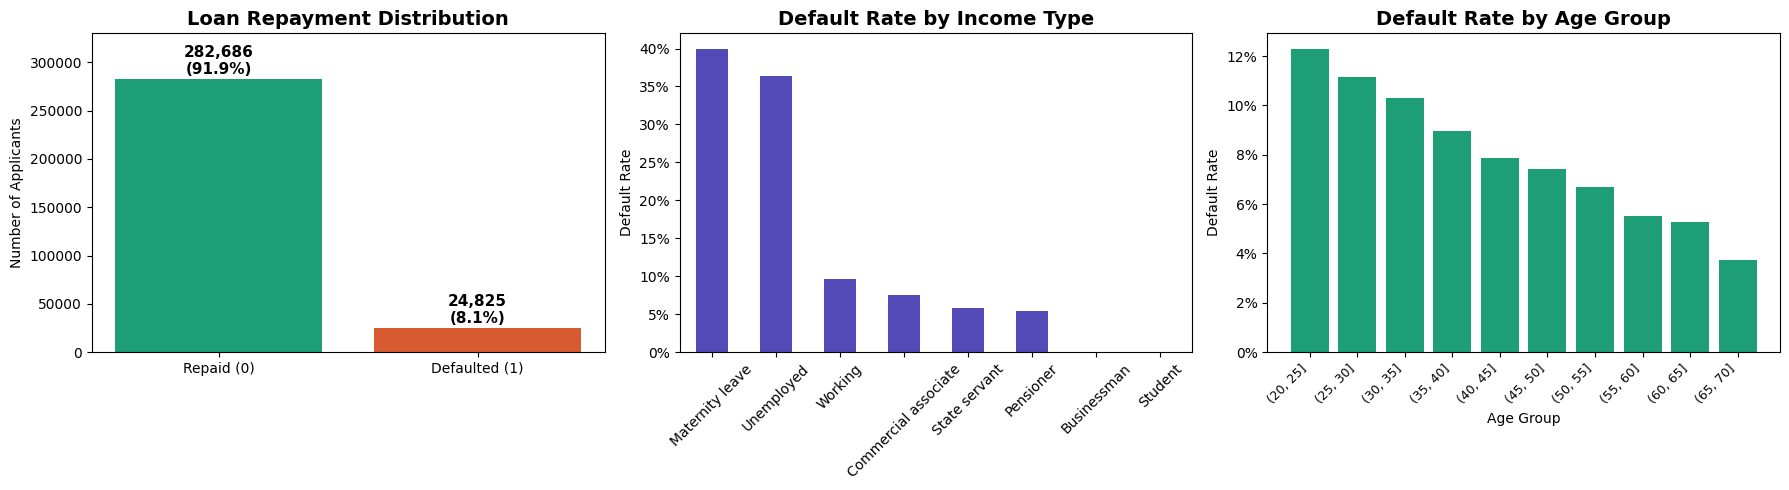

EDA charts saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Default rate bar chart
ax1 = axes[0]
default_counts = df['TARGET'].value_counts()
ax1.bar(['Repaid (0)', 'Defaulted (1)'], default_counts.values,
        color=['#1D9E75', '#D85A30'])
ax1.set_title('Loan Repayment Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Applicants')
ax1.set_ylim(0, 330000)
for i, v in enumerate(default_counts.values):
    ax1.text(i, v + 5000, f'{v:,}\n({v/len(df)*100:.1f}%)',
             ha='center', fontsize=11, fontweight='bold')

# 2. Default rate by income type
ax2 = axes[1]
income_default = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)
income_default.plot(kind='bar', ax=ax2, color='#534AB7')
ax2.set_title('Default Rate by Income Type', fontsize=14, fontweight='bold')
ax2.set_ylabel('Default Rate')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# 3. Age vs default rate — recreate AGE_BIN from scratch
ax3 = axes[2]
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365
df['AGE_BIN'] = pd.cut(df['AGE_YEARS'], bins=[20,25,30,35,40,45,50,55,60,65,70])
age_default = df.groupby('AGE_BIN', observed=True)['TARGET'].mean()
age_labels = [str(b) for b in age_default.index]
ax3.bar(range(len(age_default)), age_default.values, color='#1D9E75')
ax3.set_xticks(range(len(age_default)))
ax3.set_xticklabels(age_labels, rotation=45, ha='right', fontsize=9)
ax3.set_title('Default Rate by Age Group', fontsize=14, fontweight='bold')
ax3.set_ylabel('Default Rate')
ax3.set_xlabel('Age Group')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA charts saved!")

#Preprocessing

In [ ]:
# Drop columns with more than 50% missing values
threshold = 0.5
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >50% missing values")
df_clean = df.drop(columns=cols_to_drop)

# Fill remaining numerical missing values with median
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('TARGET')
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Dropping 41 columns with >50% missing values


/tmp/ipykernel_2053/1037634575.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


Original shape: (307511, 124)
Clean shape: (307511, 83)
Missing values remaining: 0


#Feature engineering

In [ ]:
# Create new meaningful features
df_clean['DEBT_INCOME_RATIO'] = df_clean['AMT_CREDIT'] / df_clean['AMT_INCOME_TOTAL']
df_clean['ANNUITY_INCOME_RATIO'] = df_clean['AMT_ANNUITY'] / df_clean['AMT_INCOME_TOTAL']
df_clean['CREDIT_GOODS_RATIO'] = df_clean['AMT_CREDIT'] / df_clean['AMT_GOODS_PRICE']
df_clean['INCOME_PER_PERSON'] = df_clean['AMT_INCOME_TOTAL'] / df_clean['CNT_FAM_MEMBERS']
df_clean['YEARS_EMPLOYED'] = abs(df_clean['DAYS_EMPLOYED'].clip(upper=0)) / 365
df_clean['YEARS_ID_PUBLISH'] = abs(df_clean['DAYS_ID_PUBLISH']) / 365

print("New features created:")
new_features = ['DEBT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
                'CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON',
                'YEARS_EMPLOYED', 'YEARS_ID_PUBLISH']
print(df_clean[new_features].describe().round(2))
print(f"\nFinal dataset shape: {df_clean.shape}")

New features created:
       DEBT_INCOME_RATIO  ANNUITY_INCOME_RATIO  CREDIT_GOODS_RATIO  \
count          307511.00             307511.00           307511.00   
mean                3.96                  0.18                1.12   
std                 2.69                  0.09                0.13   
min                 0.00                  0.00                0.15   
25%                 2.02                  0.11                1.00   
50%                 3.27                  0.16                1.12   
75%                 5.16                  0.23                1.20   
max                84.74                  1.88                6.00   

       INCOME_PER_PERSON  YEARS_EMPLOYED  YEARS_ID_PUBLISH  
count          307511.00       307511.00         307511.00  
mean            93106.34            5.36              8.20  
std            101373.31            6.32              4.14  
min              2812.50            0.00              0.00  
25%             47250.00            0.79  

In [ ]:
# Also add these stronger features from existing data we missed
df_clean['CREDIT_TERM'] = df_clean['AMT_CREDIT'] / df_clean['AMT_ANNUITY']
df_clean['INCOME_CREDIT_RATIO'] = df_clean['AMT_INCOME_TOTAL'] / df_clean['AMT_CREDIT']
df_clean['EMPLOYED_TO_AGE'] = df_clean['DAYS_EMPLOYED'] / df_clean['DAYS_BIRTH']
df_clean['PHONE_TO_EMPLOY'] = df_clean['DAYS_LAST_PHONE_CHANGE'] / df_clean['DAYS_EMPLOYED'].replace(0, 1)
df_clean['GOODS_CREDIT_DIFF'] = df_clean['AMT_GOODS_PRICE'] - df_clean['AMT_CREDIT']

print("New features added:")
print(df_clean[['CREDIT_TERM', 'INCOME_CREDIT_RATIO',
                'EMPLOYED_TO_AGE', 'PHONE_TO_EMPLOY',
                'GOODS_CREDIT_DIFF']].describe().round(2))

New features added:
       CREDIT_TERM  INCOME_CREDIT_RATIO  EMPLOYED_TO_AGE  PHONE_TO_EMPLOY  \
count    307511.00            307511.00        307511.00        307511.00   
mean         21.61                 0.40            -2.92             0.90   
std           7.82                 0.51             6.63             4.64   
min           6.32                 0.01           -47.49          -614.00   
25%          15.61                 0.19             0.02             0.00   
50%          20.00                 0.31             0.09             0.29   
75%          27.10                 0.50             0.19             0.79   
max          59.56               208.00             0.73          1784.00   

       GOODS_CREDIT_DIFF  
count          307511.00  
mean           -60709.71  
std             71034.27  
min           -900000.00  
25%            -99792.00  
50%            -39204.00  
75%                 0.00  
max            765000.00  


#Merging

In [ ]:
# Load the 3 extra files
print("Loading extra files...")
bureau = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/bureau.csv')
prev_app = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/previous_application.csv')
installments = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/installments_payments.csv')

print(f"Bureau shape: {bureau.shape}")
print(f"Previous applications shape: {prev_app.shape}")
print(f"Installments shape: {installments.shape}")

# ── BUREAU FEATURES ──────────────────────────────────────────
# Summarize each person's credit bureau history into single row
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT        = ('SK_ID_BUREAU', 'count'),
    BUREAU_CREDIT_SUM        = ('AMT_CREDIT_SUM', 'sum'),
    BUREAU_DEBT_SUM          = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_OVERDUE_SUM       = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    BUREAU_ACTIVE_COUNT      = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT      = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_AVG_DAYS_OVERDUE  = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_MAX_DAYS_OVERDUE  = ('CREDIT_DAY_OVERDUE', 'max'),
).reset_index()

# Debt ratio from bureau
bureau_agg['BUREAU_DEBT_RATIO'] = (
    bureau_agg['BUREAU_DEBT_SUM'] /
    bureau_agg['BUREAU_CREDIT_SUM'].replace(0, 1)
)

print(f"\nBureau features created: {bureau_agg.shape}")

# ── PREVIOUS APPLICATION FEATURES ────────────────────────────
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT           = ('SK_ID_PREV', 'count'),
    PREV_APPROVED_COUNT      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT       = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_AMT_CREDIT_MEAN     = ('AMT_CREDIT', 'mean'),
    PREV_AMT_ANNUITY_MEAN    = ('AMT_ANNUITY', 'mean'),
    PREV_DAYS_DECISION_MIN   = ('DAYS_DECISION', 'min'),
).reset_index()

# Approval rate
prev_agg['PREV_APPROVAL_RATE'] = (
    prev_agg['PREV_APPROVED_COUNT'] /
    prev_agg['PREV_APP_COUNT'].replace(0, 1)
)

print(f"Previous application features created: {prev_agg.shape}")

# ── INSTALLMENT PAYMENT FEATURES ─────────────────────────────
installments['PAYMENT_DIFF'] = (
    installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
)
installments['DAYS_LATE'] = (
    installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
).clip(lower=0)

install_agg = installments.groupby('SK_ID_CURR').agg(
    INSTALL_COUNT            = ('SK_ID_PREV', 'count'),
    INSTALL_AMT_PAYMENT_SUM  = ('AMT_PAYMENT', 'sum'),
    INSTALL_PAYMENT_DIFF_MEAN= ('PAYMENT_DIFF', 'mean'),
    INSTALL_DAYS_LATE_MEAN   = ('DAYS_LATE', 'mean'),
    INSTALL_DAYS_LATE_MAX    = ('DAYS_LATE', 'max'),
    INSTALL_LATE_COUNT       = ('DAYS_LATE', lambda x: (x > 0).sum()),
).reset_index()

# Late payment rate — most powerful new feature
install_agg['INSTALL_LATE_RATE'] = (
    install_agg['INSTALL_LATE_COUNT'] /
    install_agg['INSTALL_COUNT'].replace(0, 1)
)

print(f"Installment features created: {install_agg.shape}")

# ── MERGE ALL INTO MAIN DATASET ───────────────────────────────
df_enhanced = df_clean.copy()
df_enhanced = df_enhanced.merge(bureau_agg, on='SK_ID_CURR', how='left')
df_enhanced = df_enhanced.merge(prev_agg, on='SK_ID_CURR', how='left')
df_enhanced = df_enhanced.merge(install_agg, on='SK_ID_CURR', how='left')

# Fill missing for people with no bureau/prev history
new_cols = [c for c in df_enhanced.columns if c not in df_clean.columns]
df_enhanced[new_cols] = df_enhanced[new_cols].fillna(0)

print(f"\nOriginal features: {df_clean.shape[1]}")
print(f"Enhanced features: {df_enhanced.shape[1]}")
print(f"New features added: {df_enhanced.shape[1] - df_clean.shape[1]}")

Loading extra files...
Bureau shape: (1716428, 17)
Previous applications shape: (1670214, 37)
Installments shape: (13605401, 8)

Bureau features created: (305811, 10)
Previous application features created: (338857, 8)
Installment features created: (339587, 8)

Original features: 94
Enhanced features: 117
New features added: 23


#Models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Remove chart columns that aren't useful features
df_model = df_clean.drop(columns=['AGE_BIN', 'AGE_YEARS'], errors='ignore').copy()

# Encode categorical columns
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Split features and target
X = df_model.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_model['TARGET']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("\nBuilding models... this will take 3-5 minutes")

# Model 1 - Logistic Regression (baseline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])
print(f"\nLogistic Regression ROC-AUC: {lr_auc:.4f}")

# Model 2 - Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"Random Forest ROC-AUC:       {rf_auc:.4f}")

# Model 3 - XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight,
                                random_state=42, eval_metric='auc', verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
print(f"XGBoost ROC-AUC:             {xgb_auc:.4f}")

print("\n--- Model Comparison ---")
results = {'Logistic Regression': lr_auc, 'Random Forest': rf_auc, 'XGBoost': xgb_auc}
for model, auc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:25s}: {auc:.4f}")

Training set: (246008, 90)
Test set: (61503, 90)

Building models... this will take 3-5 minutes

Logistic Regression ROC-AUC: 0.7448
Random Forest ROC-AUC:       0.7283
XGBoost ROC-AUC:             0.7422

--- Model Comparison ---
Logistic Regression      : 0.7448
XGBoost                  : 0.7422
Random Forest            : 0.7283


#Hyperperameter tuning

In [ ]:
!pip install optuna --quiet
print("Optuna installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.4 MB/s eta 0:00:00
Optuna installed!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Starting hyperparameter tuning with Optuna...")
print("This will take 10-15 minutes — let it run!\n")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0
    }

    model = XGBClassifier(**params)

    # 3-fold cross validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train,
                            cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Run 30 trials
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest parameters found:")
for key, val in study.best_params.items():
    print(f"  {key}: {val}")
print(f"\nBest CV ROC-AUC: {study.best_value:.4f}")

# Train final model with best params
print("\nTraining final tuned model...")
best_xgb = XGBClassifier(**study.best_params, scale_pos_weight=scale_pos_weight,
                          random_state=42, eval_metric='auc', verbosity=0)
best_xgb.fit(X_train, y_train)
tuned_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])

print(f"\n=== RESULTS COMPARISON ===")
print(f"Logistic Regression (baseline): {lr_auc:.4f}")
print(f"XGBoost (default):              {xgb_auc:.4f}")
print(f"XGBoost (tuned):                {tuned_auc:.4f}")
print(f"Improvement from tuning:        +{(tuned_auc - xgb_auc):.4f}")

Starting hyperparameter tuning with Optuna...
This will take 10-15 minutes — let it run!



  0%|          | 0/30 [00:00<?, ?it/s]


Best parameters found:
  n_estimators: 490
  max_depth: 4
  learning_rate: 0.049279659546550045
  subsample: 0.8823789360909635
  colsample_bytree: 0.8713390313643639
  min_child_weight: 6

Best CV ROC-AUC: 0.7578

Training final tuned model...

=== RESULTS COMPARISON ===
Logistic Regression (baseline): 0.7448
XGBoost (default):              0.7422
XGBoost (tuned):                0.7654
Improvement from tuning:        +0.0233


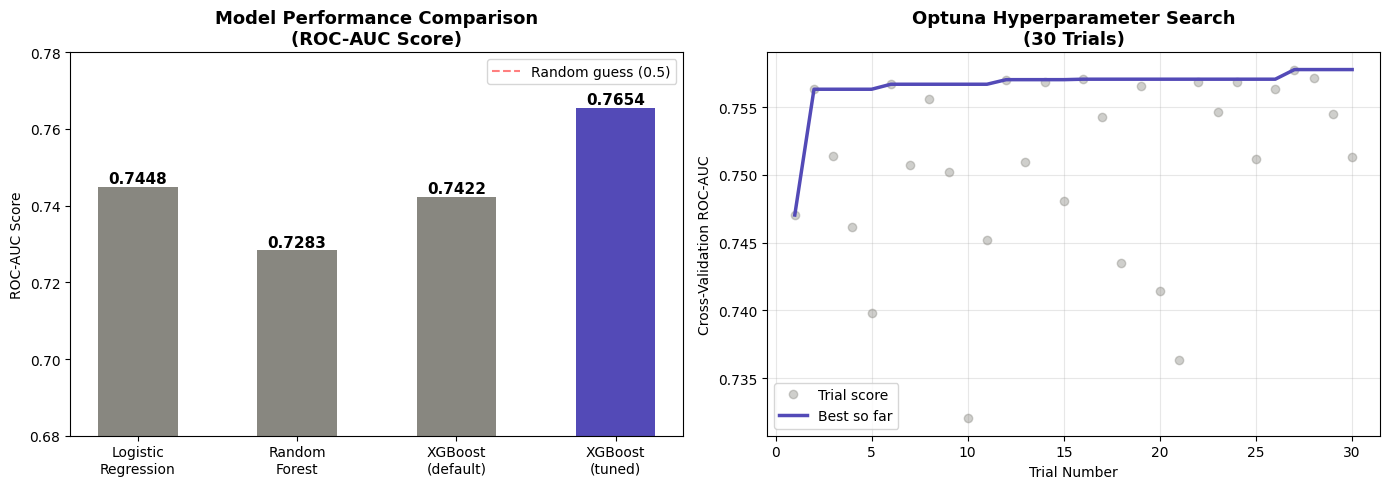

Results chart saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Model comparison bar chart
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost\n(default)', 'XGBoost\n(tuned)']
aucs = [lr_auc, rf_auc, xgb_auc, tuned_auc]
colors = ['#888780', '#888780', '#888780', '#534AB7']

ax1 = axes[0]
bars = ax1.bar(models, aucs, color=colors, width=0.5)
ax1.set_ylim(0.68, 0.78)
ax1.set_title('Model Performance Comparison\n(ROC-AUC Score)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('ROC-AUC Score')
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random guess (0.5)')
for bar, auc in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{auc:.4f}', ha='center', fontsize=11, fontweight='bold')
ax1.legend()

# Chart 2 - Optuna optimization history
ax2 = axes[1]
trial_values = [t.value for t in study.trials]
best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]
ax2.plot(range(1, len(trial_values)+1), trial_values,
         'o', alpha=0.4, color='#888780', label='Trial score')
ax2.plot(range(1, len(best_so_far)+1), best_so_far,
         '-', color='#534AB7', linewidth=2.5, label='Best so far')
ax2.set_title('Optuna Hyperparameter Search\n(30 Trials)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Trial Number')
ax2.set_ylabel('Cross-Validation ROC-AUC')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results chart saved!")

#SHAP Analysis

In [ ]:
!pip install shap --quiet
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [ ]:
import shap
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:1000])
print("Done! Now run the SHAP plots cell.")

Calculating SHAP values...
Done! Now run the SHAP plots cell.


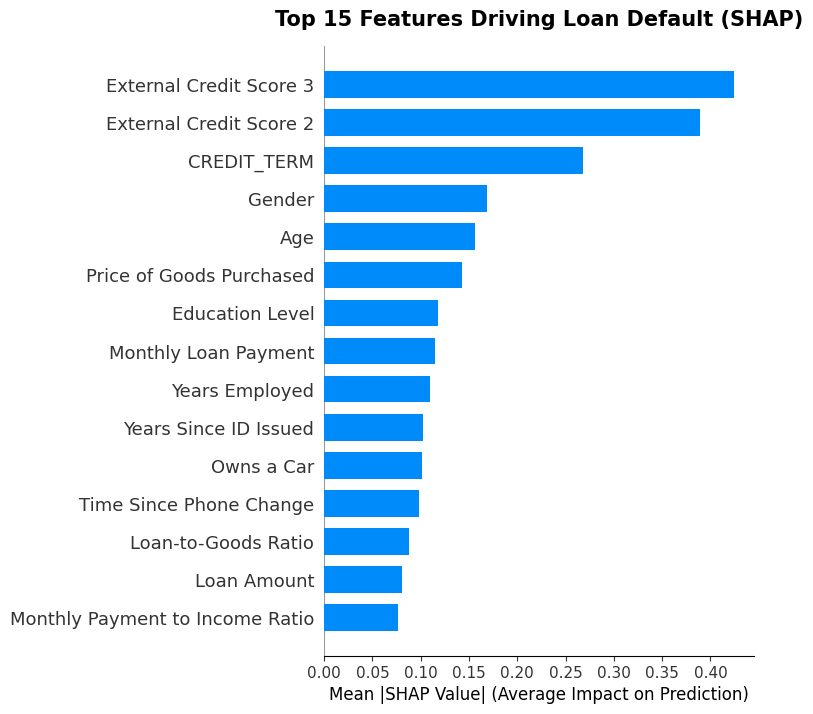

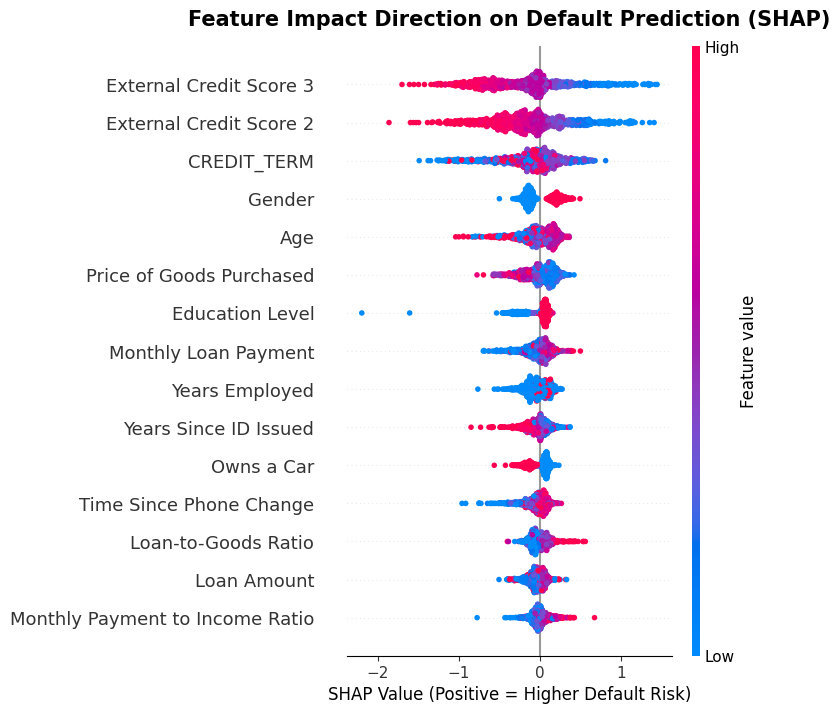

Fixed SHAP plots saved!


In [ ]:
import shap

# Rename features to plain English for charts
feature_names_readable = {
    'EXT_SOURCE_3': 'External Credit Score 3',
    'EXT_SOURCE_2': 'External Credit Score 2',
    'AMT_GOODS_PRICE': 'Price of Goods Purchased',
    'AMT_ANNUITY': 'Monthly Loan Payment',
    'CODE_GENDER': 'Gender',
    'DAYS_BIRTH': 'Age',
    'CREDIT_GOODS_RATIO': 'Loan-to-Goods Ratio',
    'NAME_EDUCATION_TYPE': 'Education Level',
    'AMT_CREDIT': 'Loan Amount',
    'FLAG_OWN_CAR': 'Owns a Car',
    'DAYS_EMPLOYED': 'Years Employed',
    'DAYS_LAST_PHONE_CHANGE': 'Time Since Phone Change',
    'YEARS_ID_PUBLISH': 'Years Since ID Issued',
    'ANNUITY_INCOME_RATIO': 'Monthly Payment to Income Ratio',
    'REGION_POPULATION_RELATIVE': 'Region Population Density'
}

# Rename columns in test set for display
X_test_display = X_test[:1000].rename(columns=feature_names_readable)

# Plot 1 - Feature importance bar chart
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_display, plot_type="bar",
                  max_display=15, show=False)
plt.title("Top 15 Features Driving Loan Default (SHAP)",
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Mean |SHAP Value| (Average Impact on Prediction)", fontsize=12)
plt.tight_layout(pad=2.0)
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 - SHAP dot plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_display,
                  max_display=15, show=False)
plt.title("Feature Impact Direction on Default Prediction (SHAP)",
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel("SHAP Value (Positive = Higher Default Risk)", fontsize=12)
plt.tight_layout(pad=2.0)
plt.savefig('shap_detailed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fixed SHAP plots saved!")

#ROC curve

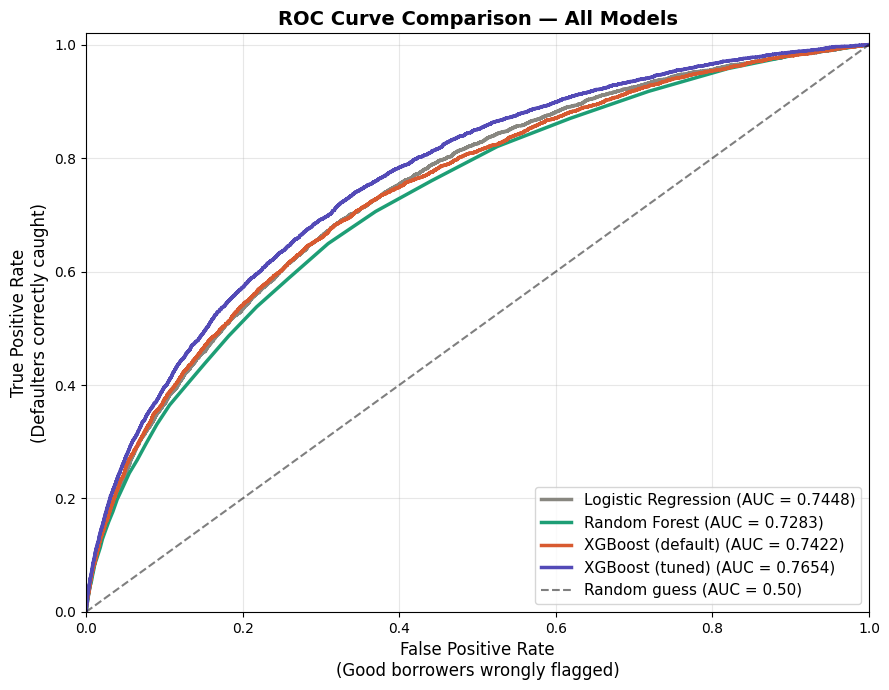

ROC curve saved!


In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))

# Plot ROC curve for each model
models_dict = {
    'Logistic Regression': (lr, X_test_scaled, lr_auc),
    'Random Forest': (rf, X_test, rf_auc),
    'XGBoost (default)': (xgb_model, X_test, xgb_auc),
    'XGBoost (tuned)': (best_xgb, X_test, tuned_auc)
}
colors = ['#888780', '#1D9E75', '#D85A30', '#534AB7']

for (name, (model, X, auc)), color in zip(models_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X)[:,1])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {auc:.4f})')

# Random guess baseline
ax.plot([0,1], [0,1], 'k--', linewidth=1.5, alpha=0.5, label='Random guess (AUC = 0.50)')

ax.set_xlabel('False Positive Rate\n(Good borrowers wrongly flagged)', fontsize=12)
ax.set_ylabel('True Positive Rate\n(Defaulters correctly caught)', fontsize=12)
ax.set_title('ROC Curve Comparison — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved!")

#SHAP waterfall

In [ ]:
def plot_clean_waterfall(ax, shap_vals, feature_names, prob, title_label):
    top_idx = np.argsort(np.abs(shap_vals))[-10:][::-1]
    top_shap = shap_vals[top_idx]
    top_names = [feature_names[i] for i in top_idx]

    sorted_idx = np.argsort(top_shap)
    top_shap = top_shap[sorted_idx]
    top_names = [top_names[i] for i in sorted_idx]

    bar_colors = ['#D85A30' if v > 0 else '#378ADD' for v in top_shap]
    bars = ax.barh(top_names, top_shap, color=bar_colors, height=0.6)

    x_range = max(abs(top_shap.max()), abs(top_shap.min()))
    offset = x_range * 0.06  # dynamic offset based on chart scale

    for bar, val in zip(bars, top_shap):
        ax.text(val + offset if val > 0 else val - offset,
                bar.get_y() + bar.get_height()/2,
                f'{val:+.2f}', va='center',
                ha='left' if val > 0 else 'right',
                fontsize=11, fontweight='bold',
                color='#D85A30' if val > 0 else '#378ADD')

    ax.axvline(x=0, color='black', linewidth=1, alpha=0.5)
    ax.set_title(f'{title_label}\nPredicted Default Probability: {prob:.1%}',
                fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('SHAP Value  (Red = increases risk,  Blue = reduces risk)', fontsize=11)
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.2)  # adds padding on both sides so labels don't clip

print("Updated function ready!")

Updated function ready!


In [ ]:
import shap

print("Calculating SHAP values for tuned model... 2-3 minutes")
explainer_tuned = shap.TreeExplainer(best_xgb)
shap_values_tuned = explainer_tuned.shap_values(X_test)

# Find high and low risk people
test_probs = best_xgb.predict_proba(X_test)[:,1]
high_risk_idx = (test_probs > 0.80).nonzero()[0][0]
low_risk_idx = (test_probs < 0.05).nonzero()[0][0]

print(f"High risk person: {test_probs[high_risk_idx]:.1%} default probability")
print(f"Low risk person:  {test_probs[low_risk_idx]:.1%} default probability")
print("Done! Now run the waterfall plot cell.")

Calculating SHAP values for tuned model... 2-3 minutes
High risk person: 85.6% default probability
Low risk person:  4.2% default probability
Done! Now run the waterfall plot cell.


Calculating SHAP values...
High risk: 85.6% | Low risk: 4.2%
Plotting...


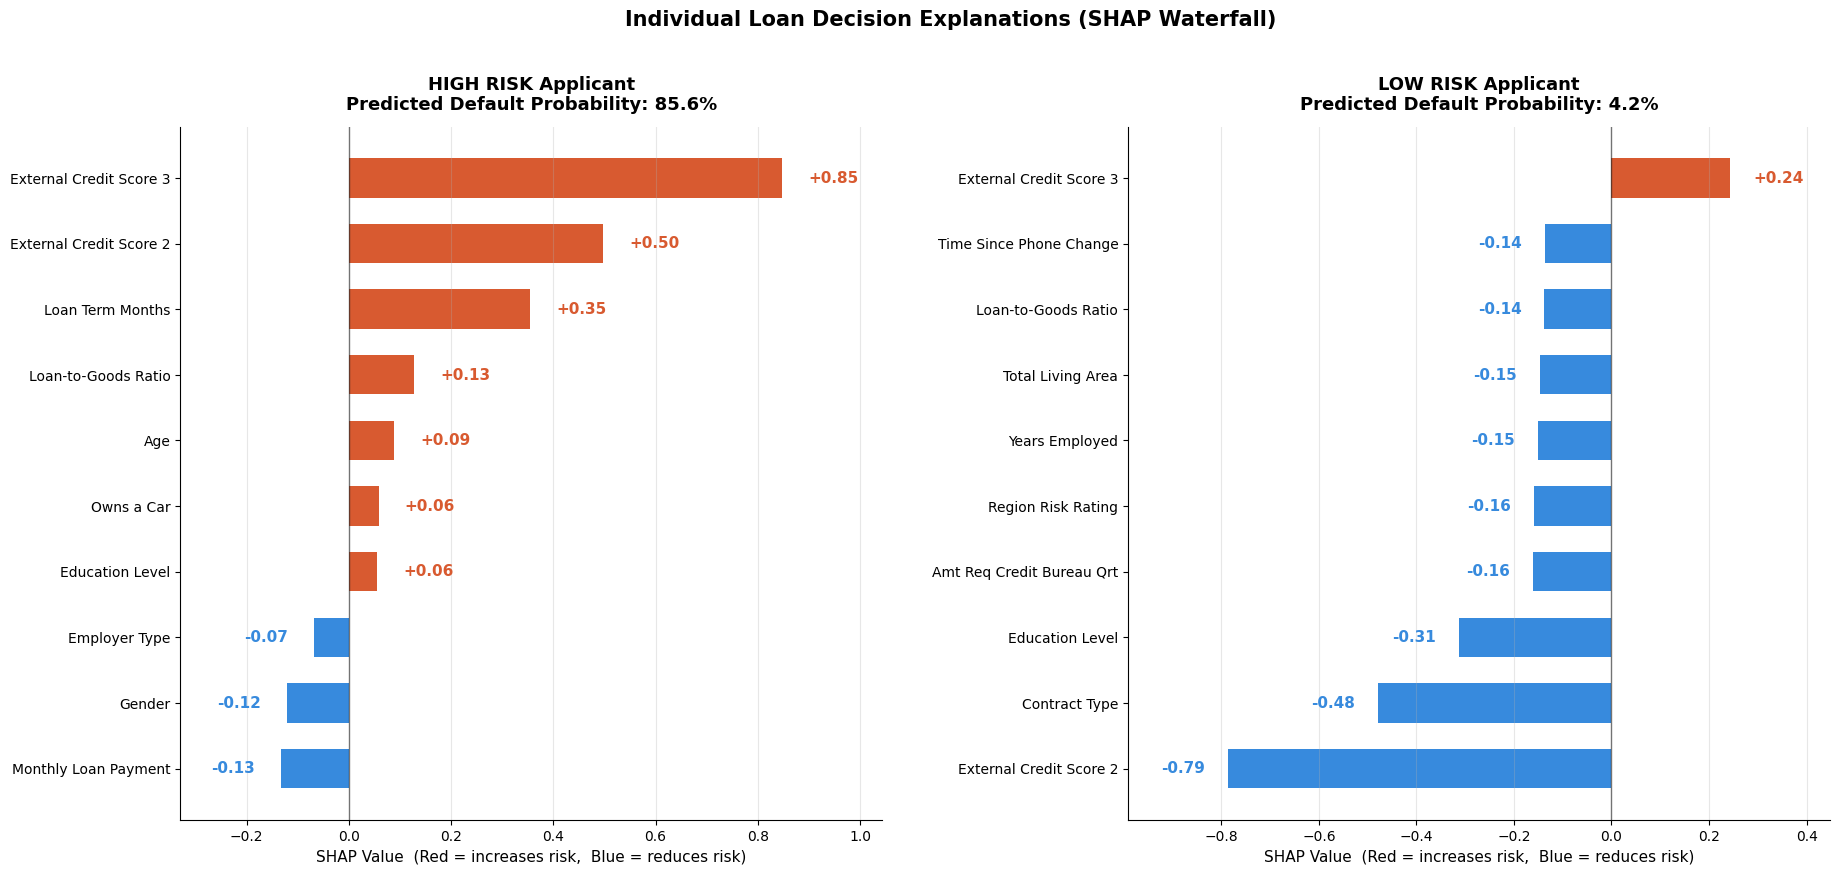

Waterfall saved!


In [ ]:
import shap
import numpy as np

all_feature_names = {
    'EXT_SOURCE_3': 'External Credit Score 3',
    'EXT_SOURCE_2': 'External Credit Score 2',
    'AMT_GOODS_PRICE': 'Price of Goods',
    'AMT_ANNUITY': 'Monthly Loan Payment',
    'CODE_GENDER': 'Gender',
    'DAYS_BIRTH': 'Age',
    'CREDIT_GOODS_RATIO': 'Loan-to-Goods Ratio',
    'NAME_EDUCATION_TYPE': 'Education Level',
    'AMT_CREDIT': 'Loan Amount',
    'FLAG_OWN_CAR': 'Owns a Car',
    'DAYS_EMPLOYED': 'Years Employed',
    'DAYS_LAST_PHONE_CHANGE': 'Time Since Phone Change',
    'YEARS_ID_PUBLISH': 'Years Since ID Issued',
    'ANNUITY_INCOME_RATIO': 'Payment-to-Income Ratio',
    'REGION_POPULATION_RELATIVE': 'Region Population Density',
    'DEBT_INCOME_RATIO': 'Debt-to-Income Ratio',
    'INCOME_PER_PERSON': 'Income Per Family Member',
    'NAME_CONTRACT_TYPE': 'Contract Type',
    'REGION_RATING_CLIENT_W_CITY': 'Region Risk Rating',
    'FLAG_DOCUMENT_3': 'Document 3 Provided',
    'TOTALAREA_MODE': 'Total Living Area',
    'AMT_REQ_CREDIT_BUREAU_YEAR': 'Credit Enquiries Past Year',
    'ORGANIZATION_TYPE': 'Employer Type',
    'CREDIT_TERM': 'Loan Term Months',
    'INCOME_CREDIT_RATIO': 'Income to Credit Ratio',
    'EMPLOYED_TO_AGE': 'Employment to Age Ratio',
    'GOODS_CREDIT_DIFF': 'Goods Credit Difference',
    'BUREAU_LOAN_COUNT': 'Number of Past Loans',
    'BUREAU_DEBT_SUM': 'Total Past Debt',
    'BUREAU_OVERDUE_SUM': 'Total Overdue Amount',
    'BUREAU_AVG_DAYS_OVERDUE': 'Avg Days Overdue',
    'BUREAU_DEBT_RATIO': 'Bureau Debt Ratio',
    'PREV_APP_COUNT': 'Previous Applications',
    'PREV_APPROVED_COUNT': 'Previous Approvals',
    'PREV_REFUSED_COUNT': 'Previous Refusals',
    'PREV_APPROVAL_RATE': 'Past Approval Rate',
    'INSTALL_LATE_RATE': 'Late Payment Rate',
    'INSTALL_DAYS_LATE_MEAN': 'Avg Days Late',
    'INSTALL_DAYS_LATE_MAX': 'Max Days Late',
}

readable_names = [all_feature_names.get(col, col.replace('_', ' ').title())
                  for col in X_test.columns]

print("Calculating SHAP values...")
explainer_tuned = shap.TreeExplainer(best_xgb)
shap_values_tuned = explainer_tuned.shap_values(X_test)
test_probs = best_xgb.predict_proba(X_test)[:,1]
high_risk_idx = (test_probs > 0.80).nonzero()[0][0]
low_risk_idx  = (test_probs < 0.05).nonzero()[0][0]
print(f"High risk: {test_probs[high_risk_idx]:.1%} | Low risk: {test_probs[low_risk_idx]:.1%}")

def plot_clean_waterfall(ax, shap_vals, feature_names, prob, title_label):
    top_idx = np.argsort(np.abs(shap_vals))[-10:][::-1]
    top_shap = shap_vals[top_idx]
    top_names = [feature_names[i] for i in top_idx]
    sorted_idx = np.argsort(top_shap)
    top_shap = top_shap[sorted_idx]
    top_names = [top_names[i] for i in sorted_idx]
    bar_colors = ['#D85A30' if v > 0 else '#378ADD' for v in top_shap]
    bars = ax.barh(top_names, top_shap, color=bar_colors, height=0.6)
    x_range = max(abs(top_shap.max()), abs(top_shap.min()))
    offset = x_range * 0.06
    for bar, val in zip(bars, top_shap):
        ax.text(val + offset if val > 0 else val - offset,
                bar.get_y() + bar.get_height()/2,
                f'{val:+.2f}', va='center',
                ha='left' if val > 0 else 'right',
                fontsize=11, fontweight='bold',
                color='#D85A30' if val > 0 else '#378ADD')
    ax.axvline(x=0, color='black', linewidth=1, alpha=0.5)
    ax.set_title(f'{title_label}\nPredicted Default Probability: {prob:.1%}',
                fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('SHAP Value  (Red = increases risk,  Blue = reduces risk)', fontsize=11)
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.2)

print("Plotting...")
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
plot_clean_waterfall(axes[0], shap_values_tuned[high_risk_idx],
                     readable_names, test_probs[high_risk_idx], 'HIGH RISK Applicant')
plot_clean_waterfall(axes[1], shap_values_tuned[low_risk_idx],
                     readable_names, test_probs[low_risk_idx], 'LOW RISK Applicant')
plt.suptitle('Individual Loan Decision Explanations (SHAP Waterfall)',
             fontsize=15, fontweight='bold', y=1.01)
plt.subplots_adjust(left=0.15, wspace=0.35)
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall saved!")

#Threshold optimization

Default threshold (0.5):
  Defaulters caught: 3,361 / 4,965 (67.7%)
  Good borrowers wrongly rejected: 16,151
  F1 Score: 0.2746

Optimal threshold for banks (0.70):
  Defaulters caught: 1,767 / 4,965 (35.6%)
  Good borrowers wrongly rejected: 4,621
  F1 Score: 0.3113


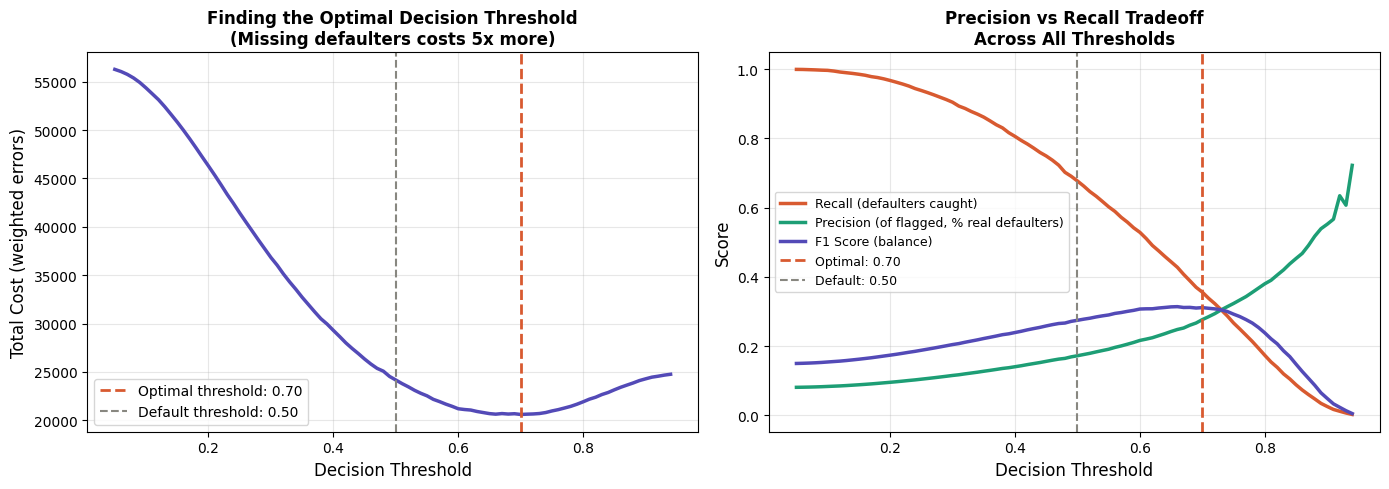

Threshold optimization saved!


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Get predicted probabilities from tuned model
y_probs = best_xgb.predict_proba(X_test)[:,1]

# Test every threshold from 0.1 to 0.9
thresholds = np.arange(0.05, 0.95, 0.01)

# For a bank: missing a defaulter costs 5x more than wrongly rejecting a good borrower
FN_COST = 5   # cost of missing a real defaulter (they default, bank loses money)
FP_COST = 1   # cost of wrongly rejecting a good borrower (lose their business)

costs, f1_scores, recall_scores, precision_scores = [], [], [], []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = (fn * FN_COST) + (fp * FP_COST)
    costs.append(total_cost)
    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    precision_scores.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

# Find optimal thresholds
best_cost_idx = np.argmin(costs)
best_f1_idx = np.argmax(f1_scores)
best_cost_thresh = thresholds[best_cost_idx]
best_f1_thresh = thresholds[best_f1_idx]

print(f"Default threshold (0.5):")
y_default = (y_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_default).ravel()
print(f"  Defaulters caught: {tp:,} / {tp+fn:,} ({tp/(tp+fn):.1%})")
print(f"  Good borrowers wrongly rejected: {fp:,}")
print(f"  F1 Score: {f1_score(y_test, y_default):.4f}")

print(f"\nOptimal threshold for banks ({best_cost_thresh:.2f}):")
y_optimal = (y_probs >= best_cost_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_optimal).ravel()
print(f"  Defaulters caught: {tp:,} / {tp+fn:,} ({tp/(tp+fn):.1%})")
print(f"  Good borrowers wrongly rejected: {fp:,}")
print(f"  F1 Score: {f1_score(y_test, y_optimal):.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Cost curve
ax1 = axes[0]
ax1.plot(thresholds, costs, color='#534AB7', linewidth=2.5)
ax1.axvline(x=best_cost_thresh, color='#D85A30', linestyle='--',
            linewidth=2, label=f'Optimal threshold: {best_cost_thresh:.2f}')
ax1.axvline(x=0.5, color='#888780', linestyle='--',
            linewidth=1.5, label='Default threshold: 0.50')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Total Cost (weighted errors)', fontsize=12)
ax1.set_title('Finding the Optimal Decision Threshold\n(Missing defaulters costs 5x more)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Chart 2 - Precision/Recall tradeoff
ax2 = axes[1]
ax2.plot(thresholds, recall_scores, color='#D85A30', linewidth=2.5, label='Recall (defaulters caught)')
ax2.plot(thresholds, precision_scores, color='#1D9E75', linewidth=2.5, label='Precision (of flagged, % real defaulters)')
ax2.plot(thresholds, f1_scores, color='#534AB7', linewidth=2.5, label='F1 Score (balance)')
ax2.axvline(x=best_cost_thresh, color='#D85A30', linestyle='--',
            linewidth=2, label=f'Optimal: {best_cost_thresh:.2f}')
ax2.axvline(x=0.5, color='#888780', linestyle='--', linewidth=1.5, label='Default: 0.50')
ax2.set_xlabel('Decision Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision vs Recall Tradeoff\nAcross All Thresholds',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Threshold optimization saved!")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

print("Preparing enhanced dataset...")

# Encode categoricals
df_model2 = df_enhanced.drop(columns=['AGE_BIN', 'AGE_YEARS'], errors='ignore').copy()
for col in df_model2.select_dtypes(include='object').columns:
    df_model2[col] = LabelEncoder().fit_transform(df_model2[col].astype(str))

X2 = df_model2.drop(columns=['TARGET', 'SK_ID_CURR'])
y2 = df_model2['TARGET']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

print(f"Enhanced training set: {X2_train.shape}")
scale_pos_weight2 = (y2_train == 0).sum() / (y2_train == 1).sum()

# Baseline XGBoost with new features
print("\nTraining XGBoost with enhanced features...")
xgb2 = xgb.XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight2,
                           random_state=42, eval_metric='auc', verbosity=0)
xgb2.fit(X2_train, y2_train)
xgb2_auc = roc_auc_score(y2_test, xgb2.predict_proba(X2_test)[:,1])
print(f"XGBoost + enhanced features ROC-AUC: {xgb2_auc:.4f}")

print("\nNow tuning with Optuna — this takes 15-20 mins...")

def objective2(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 700),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 2.0),
        'scale_pos_weight':  scale_pos_weight2,
        'random_state':      42,
        'eval_metric':       'auc',
        'verbosity':         0
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X2_train, y2_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study2 = optuna.create_study(direction='maximize')
study2.optimize(objective2, n_trials=50, show_progress_bar=True)

best_xgb2 = xgb.XGBClassifier(**study2.best_params,
                                scale_pos_weight=scale_pos_weight2,
                                random_state=42, eval_metric='auc', verbosity=0)
best_xgb2.fit(X2_train, y2_train)
tuned2_auc = roc_auc_score(y2_test, best_xgb2.predict_proba(X2_test)[:,1])

print(f"\n=== FULL RESULTS COMPARISON ===")
print(f"Original XGBoost (default):          {xgb_auc:.4f}")
print(f"Original XGBoost (tuned):            {tuned_auc:.4f}")
print(f"Enhanced XGBoost (default):          {xgb2_auc:.4f}")
print(f"Enhanced XGBoost (tuned, 50 trials): {tuned2_auc:.4f}")
print(f"Total improvement:                   +{(tuned2_auc - xgb_auc):.4f}")

Preparing enhanced dataset...
Enhanced training set: (246008, 113)

Training XGBoost with enhanced features...
XGBoost + enhanced features ROC-AUC: 0.7511

Now tuning with Optuna — this takes 15-20 mins...


  0%|          | 0/50 [00:00<?, ?it/s]


=== FULL RESULTS COMPARISON ===
Original XGBoost (default):          0.7422
Original XGBoost (tuned):            0.7654
Enhanced XGBoost (default):          0.7511
Enhanced XGBoost (tuned, 50 trials): 0.7777
Total improvement:                   +0.0356
